# 04 - Change Detection

**Goal**: Quantify how land cover changed on Lanzarote from 1990 to 2023.

**Outputs**:
- Area time series per class (km2) across 8 target years
- Transition matrix 1990 - 2023 (what converted to what, and how much)
- Change hotspot map (pixels that changed class vs stayed stable)

**Methodology**: A single GEE Random Forest (retrained from notebook 03 on CORINE 2018
labels) is applied to each year's dry-season Landsat composite. Applying a 2018
training set backwards in time is standard practice - the spectral signatures of
volcanic rock, built surfaces, and irrigated fields are physically stable across decades.

**Caveats**:
- Only 4 classes trained (no CORINE data for Forest/Woodland or Shrubland/Matorral on Lanzarote)
- CORINE 2018 labels used for all years; some pre-2018 changes become classification noise
- Landsat 7 SLC-off artefacts affect 2003-2013 imagery (scan line corrector failure)

**Phase**: 3 - Change Detection
**Classifier**: Random Forest, 200 trees, 13 spectral features
**Imagery**: Landsat Collection 2 Level-2 Surface Reflectance (USGS/NASA)

In [30]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import ee
import folium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

from pipeline.config import CLASS_NAMES, CLASS_COLORS, CORINE_REMAP, N_CLASSES
from pipeline.indices import gee_add_indices

print('All libraries loaded OK')

All libraries loaded OK


In [31]:
GEE_PROJECT   = 'project-4cb2ec4e-f113-48f1-8b5'
AOI_COORDS    = [-13.92, 28.80, -13.30, 29.30]
MAP_CENTRE    = [29.05, -13.61]
MAP_ZOOM      = 10

FEATURE_BANDS = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2',
                 'ndvi', 'ndwi', 'ndbi', 'savi', 'bsi', 'evi', 'mndwi']

CLASS_PALETTE  = [CLASS_COLORS[n] for n in CLASS_NAMES]
PIXEL_AREA_KM2 = (30 * 30) / 1e6   # 0.0009 km2 per 30m Landsat pixel

# Classes with CORINE coverage on Lanzarote (confirmed in notebook 03)
ACTIVE_CLASSES = [0, 2, 3, 4]
ACTIVE_NAMES   = [CLASS_NAMES[i] for i in ACTIVE_CLASSES]
ACTIVE_COLORS  = [CLASS_COLORS[n] for n in ACTIVE_NAMES]

# 8 target years spanning the full Landsat archive.
# 2002 used instead of 2005 - Landsat 7's Scan Line Corrector failed May 2003,
# causing striped data gaps in all L7 imagery from 2003 onward. 2002 is the last
# clean pre-SLC-off L7 year before the gap.
TARGET_YEARS  = [1990, 1995, 2000, 2002, 2010, 2015, 2020, 2023]
SENSOR_LABELS = {
    1990: 'Landsat 5',
    1995: 'Landsat 5',
    2000: 'Landsat 7',
    2002: 'Landsat 7 (last pre-SLC-off)',
    2010: 'Landsat 7',
    2015: 'Landsat 8',
    2020: 'Landsat 8',
    2023: 'Landsat 9',
}

ee.Initialize(project=GEE_PROJECT)
aoi = ee.Geometry.Rectangle(AOI_COORDS)

print('GEE initialised')
print(f'Target years  : {TARGET_YEARS}')
print(f'Active classes: {ACTIVE_NAMES}')
print(f'Pixel area    : {PIXEL_AREA_KM2} km2')

GEE initialised
Target years  : [1990, 1995, 2000, 2002, 2010, 2015, 2020, 2023]
Active classes: ['Urban/Built-up', 'Water/Wetland', 'Agriculture', 'Barren/Volcanic']
Pixel area    : 0.0009 km2


## 1. Train GEE Classifier

Retrain the same GEE Random Forest from notebook 03.
750 stratified samples per class from CORINE 2018 labels,
extracted from the 2023 composite as the feature source.

This cell takes ~30-60 s (one `stratifiedSample` + `smileRandomForest.train`).

In [32]:
# Remap CORINE to our 6-class scheme
from_vals = list(CORINE_REMAP.keys())
to_vals   = list(CORINE_REMAP.values())

corine_raw      = ee.Image('COPERNICUS/CORINE/V20/100m/2018').select('landcover').clip(aoi)
corine_remapped = corine_raw.remap(from_vals, to_vals, defaultValue=-1).rename('label')
corine_labels   = corine_remapped.updateMask(corine_remapped.gte(0))


def make_composite(year):
    """Cloud-masked, scaled, index-enriched dry-season Landsat composite."""
    def mask_clouds(img):
        qa = img.select('QA_PIXEL')
        return img.updateMask(
            qa.bitwiseAnd(1 << 3).eq(0)          # cloud
              .And(qa.bitwiseAnd(1 << 4).eq(0))   # shadow
        )

    def scale_sr(img):
        return img.addBands(
            img.select('SR_B.').multiply(0.0000275).add(-0.2),
            overwrite=True,
        )

    col_id = ('LANDSAT/LC09/C02/T1_L2' if year >= 2022 else
              'LANDSAT/LC08/C02/T1_L2' if year >= 2013 else
              'LANDSAT/LE07/C02/T1_L2' if year >= 1999 else
              'LANDSAT/LT05/C02/T1_L2')
    b_in  = (['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'] if year >= 2013
             else ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])
    b_out = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']

    comp = (ee.ImageCollection(col_id)
            .filterBounds(aoi)
            .filterDate(f'{year}-05-01', f'{year}-09-30')
            .filter(ee.Filter.lt('CLOUD_COVER', 80))   # per-pixel mask handles clouds
            .map(mask_clouds)
            .map(scale_sr)
            .select(b_in, b_out)
            .median()
            .clip(aoi))
    return gee_add_indices(comp)


# Build training image from 2023 composite + CORINE labels
composite_2023 = make_composite(2023)
training_image = composite_2023.select(FEATURE_BANDS).addBands(corine_labels)

SAMPLES_PER_CLASS = 750
samples_gee = training_image.stratifiedSample(
    numPoints     = SAMPLES_PER_CLASS,
    classBand     = 'label',
    region        = aoi,
    scale         = 100,
    classValues   = ACTIVE_CLASSES,
    classPoints   = [SAMPLES_PER_CLASS] * len(ACTIVE_CLASSES),
    seed          = 42,
    geometries    = False,
)

# Train
gee_clf = ee.Classifier.smileRandomForest(numberOfTrees=200, seed=42).train(
    features        = samples_gee,
    classProperty   = 'label',
    inputProperties = FEATURE_BANDS,
)

print('GEE Random Forest trained')
print(f'{SAMPLES_PER_CLASS} px/class x {len(ACTIVE_CLASSES)} classes = '
      f'{SAMPLES_PER_CLASS * len(ACTIVE_CLASSES)} training pixels')

GEE Random Forest trained
750 px/class x 4 classes = 3000 training pixels


## 2. Classify All Target Years

Apply the trained classifier to each year's composite.
Everything runs server-side on GEE - no raster data is downloaded.

In [33]:
print('Classifying target years...\n')

classified = {}
land_mask = corine_labels.mask()   # CORINE land mask - excludes ocean pixels

for year in TARGET_YEARS:
    comp = make_composite(year)
    cls  = (comp.select(FEATURE_BANDS)
               .classify(gee_clf)
               .rename('classification')
               .updateMask(land_mask)   # exclude ocean / no-data pixels
               .toInt()
               .clip(aoi))
    classified[year] = cls
    print(f'  {year}  [{SENSOR_LABELS[year]}]')

print(f'\nAll {len(TARGET_YEARS)} years classified')

Classifying target years...

  1990  [Landsat 5]
  1995  [Landsat 5]
  2000  [Landsat 7]
  2002  [Landsat 7 (last pre-SLC-off)]
  2010  [Landsat 7]
  2015  [Landsat 8]
  2020  [Landsat 8]
  2023  [Landsat 9]

All 8 years classified


In [34]:
# Compute class areas via frequency histogram (one getInfo() call per year)
print('Computing class areas...\n')

rows = []
for year in TARGET_YEARS:
    hist = classified[year].reduceRegion(
        reducer   = ee.Reducer.frequencyHistogram(),
        geometry  = aoi,
        scale     = 30,
        maxPixels = 1e9,
    ).getInfo()

    counts = hist.get('classification', {})
    for cls_idx in ACTIVE_CLASSES:
        n_pixels = int(round(float(counts.get(str(cls_idx), 0))))
        rows.append({
            'year':       year,
            'class_idx':  cls_idx,
            'class_name': CLASS_NAMES[cls_idx],
            'n_pixels':   n_pixels,
            'area_km2':   n_pixels * PIXEL_AREA_KM2,
        })
    print(f'  {year}: {dict(counts)}')

area_df = pd.DataFrame(rows)
pivot   = area_df.pivot(index='year', columns='class_name', values='area_km2')
print('\nArea summary (km2):')
print(pivot.round(1).to_string())

Computing class areas...

  1990: {'0': 399363, '2': 64864, '3': 225934, '4': 210208}
  1995: {'0': 330668, '2': 65953, '3': 151458, '4': 293025}
  2000: {'0': 217877, '2': 16274, '3': 353950, '4': 475628}
  2002: {'0': 259899, '2': 7971, '3': 254177, '4': 524406}
  2010: {'0': 187220, '2': 18844, '3': 259957, '4': 421391}
  2015: {'0': 163447, '2': 4360, '3': 373047, '4': 521645}
  2020: {'0': 188948, '2': 5924, '3': 360254, '4': 502829}
  2023: {'0': 153591, '2': 5600, '3': 367747, '4': 532322}

Area summary (km2):
class_name  Agriculture  Barren/Volcanic  Urban/Built-up  Water/Wetland
year                                                                   
1990              203.3            189.2           359.4           58.4
1995              136.3            263.7           297.6           59.4
2000              318.6            428.1           196.1           14.6
2002              228.8            472.0           233.9            7.2
2010              234.0            379.3     

## 3. Area Time Series

How many km2 of each land cover class was present each year?
Trends above noise level (>~5 km2) are likely real; smaller fluctuations
may reflect inter-annual compositing variation or classifier noise.

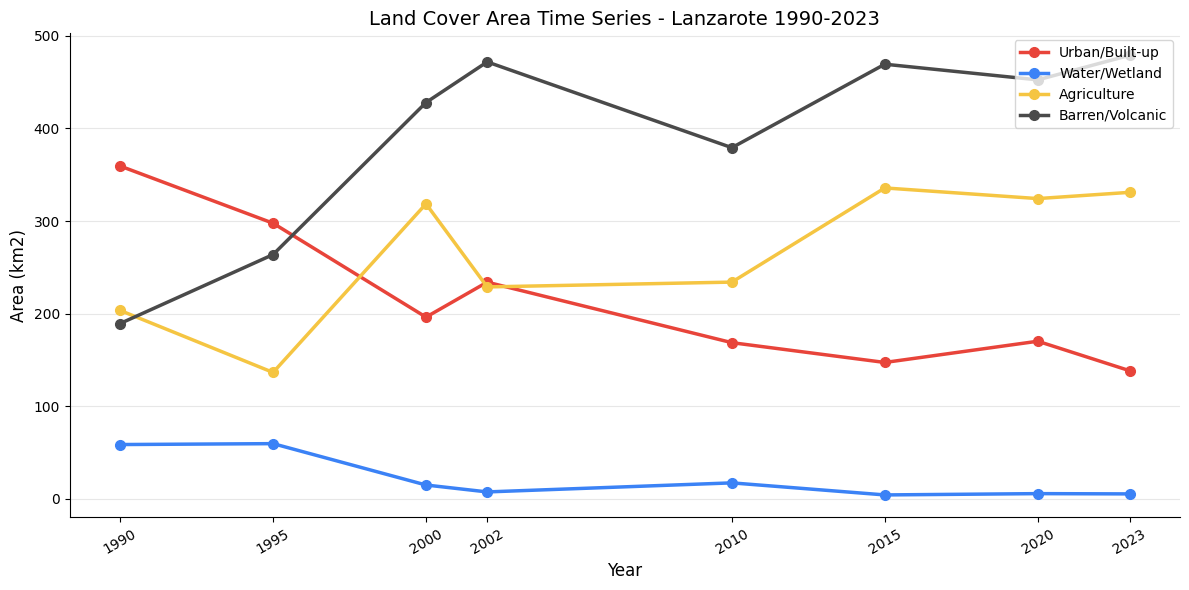

Saved to data/processed/area_time_series.png


In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

for cls_idx in ACTIVE_CLASSES:
    name   = CLASS_NAMES[cls_idx]
    color  = CLASS_COLORS[name]
    subset = area_df[area_df['class_name'] == name].sort_values('year')
    ax.plot(subset['year'], subset['area_km2'],
            marker='o', linewidth=2.5, markersize=7,
            color=color, label=name)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Area (km2)', fontsize=12)
ax.set_title('Land Cover Area Time Series - Lanzarote 1990-2023', fontsize=14)
ax.set_xticks(TARGET_YEARS)
ax.set_xticklabels(TARGET_YEARS, rotation=30)
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/area_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/area_time_series.png')

## 4. Transition Matrix 1990 - 2023

How many km2 of each class converted to each other class over the full period?

- **Diagonal** = stable (no change)
- **Off-diagonal** = class transitions

Encoding trick: pack `from_class * 10 + to_class` into a single raster band,
then count with `frequencyHistogram` - one GEE call gives every transition.

In [36]:
t1 = classified[1990]
t2 = classified[2023]

# Encode: from_class * 10 + to_class  (e.g. 34 = Agriculture -> Barren)
transition_img = t1.multiply(10).add(t2).rename('transition')

trans_hist = transition_img.reduceRegion(
    reducer   = ee.Reducer.frequencyHistogram(),
    geometry  = aoi,
    scale     = 30,
    maxPixels = 1e9,
).getInfo()['transition']

# Build km2 matrix (rows = from, columns = to)
trans_df = pd.DataFrame(0.0, index=ACTIVE_NAMES, columns=ACTIVE_NAMES)

for key, count in trans_hist.items():
    combined  = int(float(key))
    from_cls  = combined // 10
    to_cls    = combined  % 10
    if from_cls in ACTIVE_CLASSES and to_cls in ACTIVE_CLASSES:
        from_name = CLASS_NAMES[from_cls]
        to_name   = CLASS_NAMES[to_cls]
        trans_df.loc[from_name, to_name] += count * PIXEL_AREA_KM2

# Row/column totals
trans_display = trans_df.copy()
trans_display['TOTAL (from)'] = trans_display.sum(axis=1)
trans_display.loc['TOTAL (to)'] = trans_display.sum(axis=0)

stable_km2   = sum(trans_df.loc[n, n] for n in ACTIVE_NAMES)
total_km2    = trans_df.values.sum()
changed_pct  = (1 - stable_km2 / total_km2) * 100 if total_km2 > 0 else 0

print('Transition matrix 1990 - 2023 (km2):\n')
print(trans_display.round(1).to_string())
print(f'\nStable area  : {stable_km2:.1f} km2 ({100 - changed_pct:.1f}%)')
print(f'Changed area : {total_km2 - stable_km2:.1f} km2 ({changed_pct:.1f}%)')

Transition matrix 1990 - 2023 (km2):

                 Urban/Built-up  Water/Wetland  Agriculture  Barren/Volcanic  TOTAL (from)
Urban/Built-up             97.9            0.8        117.9            142.4         359.1
Water/Wetland               1.3            3.0          6.0             47.8          58.0
Agriculture                18.0            0.2        105.8             79.1         203.1
Barren/Volcanic             6.8            0.2         55.6            126.2         188.8
TOTAL (to)                124.1            4.2        285.3            395.5         809.1

Stable area  : 332.9 km2 (41.2%)
Changed area : 476.1 km2 (58.8%)


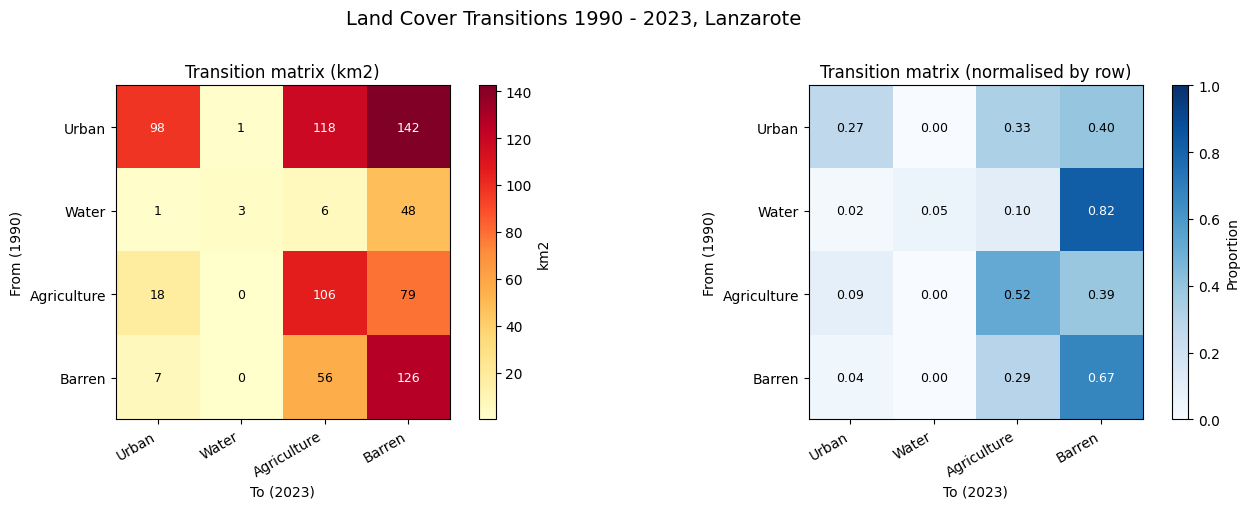

Saved to data/processed/transition_matrix_1990_2023.png


In [37]:
# Two-panel heatmap: raw km2 (left) and row-normalised (right)
trans_norm = trans_df.div(trans_df.sum(axis=1), axis=0).fillna(0)
short      = [n.split('/')[0] for n in ACTIVE_NAMES]
n_active   = len(ACTIVE_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Raw km2 ---
ax  = axes[0]
im  = ax.imshow(trans_df.values, cmap='YlOrRd')
fig.colorbar(im, ax=ax, label='km2')
ax.set_xticks(range(n_active));  ax.set_yticks(range(n_active))
ax.set_xticklabels(short, rotation=30, ha='right')
ax.set_yticklabels(short)
ax.set_xlabel('To (2023)');  ax.set_ylabel('From (1990)')
ax.set_title('Transition matrix (km2)', fontsize=12)
for i in range(n_active):
    for j in range(n_active):
        val = trans_df.iloc[i, j]
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=9,
                color='white' if val > trans_df.values.max() * 0.6 else 'black')

# --- Row-normalised ---
ax2 = axes[1]
im2 = ax2.imshow(trans_norm.values, cmap='Blues', vmin=0, vmax=1)
fig.colorbar(im2, ax=ax2, label='Proportion')
ax2.set_xticks(range(n_active));  ax2.set_yticks(range(n_active))
ax2.set_xticklabels(short, rotation=30, ha='right')
ax2.set_yticklabels(short)
ax2.set_xlabel('To (2023)');  ax2.set_ylabel('From (1990)')
ax2.set_title('Transition matrix (normalised by row)', fontsize=12)
for i in range(n_active):
    for j in range(n_active):
        val = trans_norm.iloc[i, j]
        ax2.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                 color='white' if val > 0.6 else 'black')

plt.suptitle('Land Cover Transitions 1990 - 2023, Lanzarote', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/transition_matrix_1990_2023.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/transition_matrix_1990_2023.png')

## 5. Change Hotspot Map

Pixels that changed class between 1990 and 2023 (orange) vs pixels that stayed
stable (dark background).

Toggle layers in the top-right to compare the 1990 and 2023 classified maps.

In [38]:
def add_ee_layer(fmap, image, vis, name, shown=True, opacity=0.85):
    mid = ee.Image(image).getMapId(vis)
    folium.raster_layers.TileLayer(
        tiles=mid['tile_fetcher'].url_format,
        attr='GEE / USGS / Copernicus', name=name,
        overlay=True, control=True, show=shown, opacity=opacity,
    ).add_to(fmap)


classified_vis = {'min': 0, 'max': 5, 'palette': CLASS_PALETTE}

# Binary change mask: 1 = changed, 0 = stable
change_mask = classified[1990].neq(classified[2023]).rename('change')
change_vis  = {'min': 0, 'max': 1, 'palette': ['#1a1a1a', '#FF4500']}

m = folium.Map(location=MAP_CENTRE, zoom_start=MAP_ZOOM, tiles='CartoDB dark_matter')
add_ee_layer(m, classified[1990], classified_vis, 'Land cover 1990',         shown=False)
add_ee_layer(m, classified[2023], classified_vis, 'Land cover 2023',         shown=False)
add_ee_layer(m, change_mask,      change_vis,     'Changed 1990-2023',       shown=True)
folium.LayerControl(collapsed=False).add_to(m)

# Legend
lg  = '<div style="position:fixed;bottom:30px;left:30px;z-index:999;'
lg += 'background:white;padding:10px;border-radius:5px;font-size:12px;">'
lg += '<b>Land Cover Classes</b><br>'
for name, color in CLASS_COLORS.items():
    lg += (f'<div><span style="background:{color};width:12px;height:12px;'
           f'display:inline-block;margin-right:5px;"></span>{name}</div>')
lg += '<hr style="margin:6px 0">'
lg += ('<div><span style="background:#FF4500;width:12px;height:12px;'
       'display:inline-block;margin-right:5px;"></span>Changed 1990-2023</div>')
lg += '</div>'
m.get_root().html.add_child(folium.Element(lg))

display(m)

In [39]:
import pathlib
processed = pathlib.Path('../data/processed')
processed.mkdir(parents=True, exist_ok=True)

area_df.to_csv(processed / 'area_time_series.csv', index=False)
trans_df.to_csv(processed / 'transition_matrix_1990_2023.csv')

print('Saved:')
print(f'  {processed}/area_time_series.csv')
print(f'  {processed}/transition_matrix_1990_2023.csv')

Saved:
  ..\data\processed/area_time_series.csv
  ..\data\processed/transition_matrix_1990_2023.csv


## Summary & Next Steps

### Key outputs
- **Area time series** - how each class evolved over 33 years
- **Transition matrix** - exact km2 that converted between classes 1990-2023
- **Change hotspot map** - where on the island change was concentrated

### Accuracy note
OA = 66.7%, Kappa = 0.52 (notebook 03 validation).
The main confusion is Agriculture vs Barren/Volcanic - expected on Lanzarote due to
enarenado farming (seeds planted under volcanic ash). Treat relative trends as more
reliable than absolute class areas.

### Phase 4 next steps
- Notebook 05: final summary maps and visual report
- FastAPI backend serving the time series and classified rasters
- React frontend dashboard